In [1]:
# Cell 1
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer

# Set plot style for professional presentation slides
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [8]:
# Cell 2
# Define relative paths based on your folder structure
EXCEL_PATH = "Benchmark Dataset.xlsx"
BASELINE_JSON_PATH = "./Baseline Model/output_payload_baseline.json"
ADVANCED_JSON_PATH = "./Advanced Model/output_payload.json"

# Load the Gold Standard Excel
df_benchmark = pd.read_excel(EXCEL_PATH)
print(f"Loaded {len(df_benchmark)} benchmark questions.")

# Load the Baseline outputs
with open(BASELINE_JSON_PATH, 'r', encoding='utf-8') as f:
    baseline_data = json.load(f)["results"]

# Load the Advanced outputs
with open(ADVANCED_JSON_PATH, 'r', encoding='utf-8') as f:
    advanced_data = json.load(f)["results"]
    
print("✅ Output payloads loaded successfully.")

Loaded 30 benchmark questions.
✅ Output payloads loaded successfully.


In [9]:
# Cell 3
def calculate_metrics(benchmark_df, results_data, model_name):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    
    total_rouge1 = 0
    total_rougeL = 0
    hits = 0
    mrr_sum = 0
    
    # Convert results to a dictionary for easy lookup by query_id
    results_dict = {str(item["query_id"]): item for item in results_data}
    
    for _, row in benchmark_df.iterrows():
        q_id = str(row['id'])
        gold_answer = str(row['gold_answer'])
        
        # Extract the core topic from "Wikipedia - Topic" to check retrieval
        gold_topic = str(row['source_reference']).split('-')[-1].strip().lower()
        
        if q_id not in results_dict:
            continue
            
        result = results_dict[q_id]
        generated_answer = result["response"]
        retrieved_contexts = result.get("retrieved_context", [])
        
        # --- 1. GENERATION METRICS (ROUGE) ---
        scores = scorer.score(gold_answer, generated_answer)
        total_rouge1 += scores['rouge1'].fmeasure
        total_rougeL += scores['rougeL'].fmeasure
        
        # --- 2. RETRIEVAL METRICS (Hit Rate & MRR) ---
        # Check if the core topic is mentioned in the retrieved text
        found_hit = False
        for rank, doc in enumerate(retrieved_contexts, start=1):
            if gold_topic in doc["text"].lower():
                if not found_hit:
                    hits += 1
                    mrr_sum += (1.0 / rank)
                    found_hit = True
                    
    num_queries = len(benchmark_df)
    
    return {
        "Model": model_name,
        "Avg ROUGE-1": round(total_rouge1 / num_queries, 4),
        "Avg ROUGE-L": round(total_rougeL / num_queries, 4),
        "Hit Rate@5": f"{round((hits / num_queries) * 100, 1)}%",
        "MRR": round(mrr_sum / num_queries, 4)
    }

print("✅ Evaluation logic defined.")

✅ Evaluation logic defined.


In [10]:
# Cell 4
# Run the evaluation on both models
baseline_metrics = calculate_metrics(df_benchmark, baseline_data, "Baseline (MiniLM + Flat)")
advanced_metrics = calculate_metrics(df_benchmark, advanced_data, "Advanced (BGE + Cross-Encoder)")

# Create a comparison DataFrame
comparison_df = pd.DataFrame([baseline_metrics, advanced_metrics])

# Calculate absolute improvement
improvement = {
    "Model": "Improvement (Δ)",
    "Avg ROUGE-1": f"+{round(advanced_metrics['Avg ROUGE-1'] - baseline_metrics['Avg ROUGE-1'], 4)}",
    "Avg ROUGE-L": f"+{round(advanced_metrics['Avg ROUGE-L'] - baseline_metrics['Avg ROUGE-L'], 4)}",
    "Hit Rate@5": f"+{round(float(advanced_metrics['Hit Rate@5'].strip('%')) - float(baseline_metrics['Hit Rate@5'].strip('%')), 1)}%",
    "MRR": f"+{round(advanced_metrics['MRR'] - baseline_metrics['MRR'], 4)}"
}

# Add improvement row and display
final_report = pd.concat([comparison_df, pd.DataFrame([improvement])], ignore_index=True)
final_report.set_index("Model", inplace=True)

display(final_report)

,Avg ROUGE-1,Avg ROUGE-L,Hit Rate@5,MRR
Model,,,,
Baseline (MiniLM + Flat),0.1259,0.1073,13.3%,0.1333
Advanced (BGE + Cross-Encoder),0.2048,0.1662,40.0%,0.3333
Improvement (Δ),+0.0789,+0.0589,+26.7%,+0.2


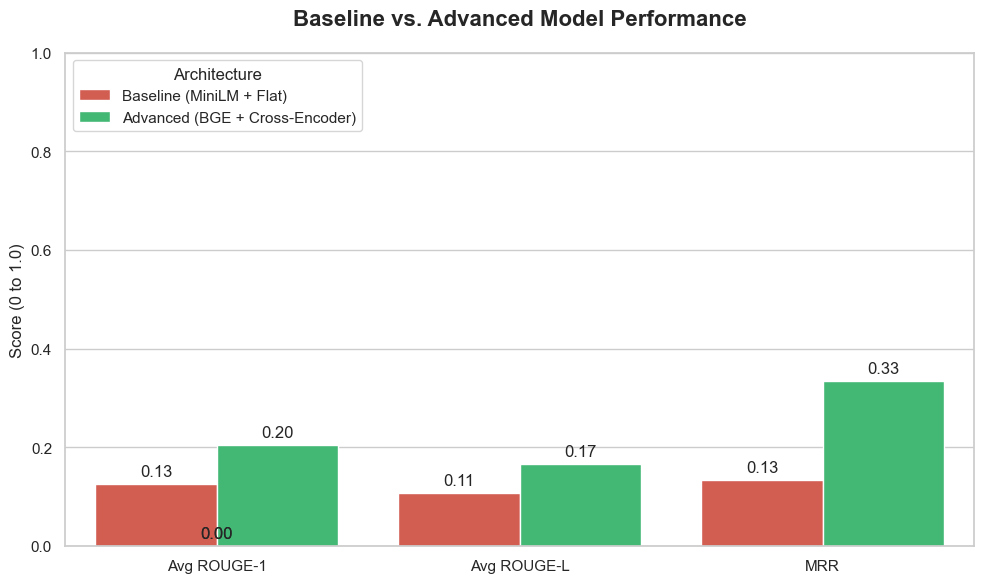

In [11]:
# Cell 5
# Prepare data for plotting
plot_df = pd.melt(comparison_df, id_vars=['Model'], value_vars=['Avg ROUGE-1', 'Avg ROUGE-L', 'MRR'], 
                  var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df, palette=['#e74c3c', '#2ecc71'])

plt.title('Baseline vs. Advanced Model Performance', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0 to 1.0)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 1.0)
plt.legend(title='Architecture', loc='upper left')

# Add score labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig('performance_comparison_chart.png', dpi=300) # Saves the chart so you can put it in your slides!
plt.show()